Intalación modelos iniciales para empezar el tunning

In [ ]:
!pip uninstall -y -q gradio gradio-client
!pip install -q unsloth unsloth_zoo trl
!pip install -q --no-cache-dir "transformers==5.5.0"

Hay que reiniciar la instancia despues de la instalación
Depues con lo siguiente confirmo que se instalo todo bien

In [ ]:
import unsloth
import torch, transformers, peft, trl
from transformers.models.auto.configuration_auto import CONFIG_MAPPING_NAMES

print("transformers ", transformers.__version__)
print("gemma4       ", 'gemma4' in CONFIG_MAPPING_NAMES)
print("trl          ", trl.__version__)
print("GPU          ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else ">>> SIN GPU <<<")

aseguramos la conexión con DRIVE donde tengo mis fotos para hacerle TUNNING en al modelo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Ahora definimos los valores a utilizar en todas las demas secciones

In [ ]:
MODELO_BASE      = "unsloth/gemma-4-E2B-it"

RESOLUCION       = 896
RECORTE_SUPERIOR = 1.0
EPOCAS           = 3
SEMILLA          = 42

# --- DÓNDE ESTÁN TUS DATOS (Google Drive) ---
BASE             = '/content/drive/MyDrive/dataset_facturas'
RUTA_JSON        = BASE + '/data.json'
RUTA_IMG_DRIVE   = BASE + '/imagenes'
RUTA_MODELO_LORA = BASE + '/modelo_facturas_lora'

RUTA_IMAGENES    = '/content/imagenes'
DIR_CHECKPOINTS  = '/content/outputs'

import os
from pathlib import Path
os.makedirs(DIR_CHECKPOINTS, exist_ok=True)
os.makedirs(RUTA_MODELO_LORA, exist_ok=True)
print("Configuración cargada.")

Confirmamos que los valores de JSON que puse en mi archivo data funcionen

In [ ]:
import json

with open(RUTA_JSON, encoding='utf-8') as f:
    datos = json.load(f)

print("Total de ejemplos:", len(datos))
print("Claves del primer registro:", list(datos[0].keys()))
print()
print(json.dumps(datos[0], indent=2, ensure_ascii=False)[:800])

Verificar las imágenes y copiarlas a local (al local del COLAB desde el DRIVE)

In [ ]:
import os
from pathlib import Path

# 1) Refrescar la vista de Drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

# 2) Detectar la clave que guarda el nombre de la imagen
CANDIDATAS = ['imagen', 'Imagen', 'image', 'archivo', 'file']
CLAVE_IMG = next((k for k in CANDIDATAS if k in datos[0]), None)
assert CLAVE_IMG, f"No encuentro la clave de imagen. Claves: {list(datos[0].keys())}"
print("Clave de imagen:", CLAVE_IMG)

# 3) Comparar en las dos direcciones
EXT = {'.jpg', '.jpeg', '.png'}
en_drive = {f for f in os.listdir(RUTA_IMG_DRIVE) if Path(f).suffix.lower() in EXT}
en_json  = {d[CLAVE_IMG] for d in datos}

faltan = sorted(en_json - en_drive)
sobran = sorted(en_drive - en_json)

print(f"\nEn JSON: {len(en_json)} | En Drive: {len(en_drive)}")
print("Faltan en Drive:", faltan or "ninguna")
print("Sobran en Drive:", sobran or "ninguna")

# 4) Copiar a disco local
!rm -rf {RUTA_IMAGENES}
!cp -r {RUTA_IMG_DRIVE} {RUTA_IMAGENES}
print("\nCopiadas a local:", len(os.listdir(RUTA_IMAGENES)))

# 5) Frenar si algo no cuadra
if faltan:
    raise SystemExit(
        f"\n>>> FALTAN {len(faltan)} IMÁGENES.\n"
        f"    Súbelas a Drive (o corrige el nombre) y vuelve a ejecutar esta celda.\n"
        f"    Si no las tienes, ejecuta la celda de descarte de abajo."
    )

print(">>> Todo correcto")

Ahora viene la parte dura del entranamiento real, como ya traje las imagenes a la instalación del COLAB vamos a descargar el modelo en esta máquina virtual (esto puede demorar un tiempo variable y ser un poco alto ya que depende de la red y puede pesar varios GB)

El script se ha echo para que pueda trabajar desde cero (o sea sin un modelo ya entrenado o con un que ya se entreno para seguir una tarea donde se dejo)

- Si en `RUTA_MODELO_LORA` hay un `adapter_config.json` va a **continuar**: carga tu LoRA entrenado.
- Si la carpeta está vacía **desde cero**: carga el modelo base e instala un LoRA nuevo.


In [ ]:
import unsloth
from unsloth import FastModel
from pathlib import Path

HAY_LORA = Path(RUTA_MODELO_LORA, 'adapter_config.json').exists()

if HAY_LORA:
    print(">>> MODO CONTINUAR: se encontró un LoRA entrenado, se carga tal cual.")
    print(">>> Salta el paso 9 (entrenar) y el 10 (guardar); ve directo al paso 11.\n")
    model, tokenizer = FastModel.from_pretrained(
        RUTA_MODELO_LORA,
        load_in_4bit = True,
        dtype = None,
    )
else:
    print(">>> MODO DESDE CERO: no hay LoRA previo, se carga el modelo base.\n")
    model, tokenizer = FastModel.from_pretrained(
        MODELO_BASE,
        load_in_4bit = True,
        dtype = None,
    )
    model = FastModel.get_peft_model(
        model,
        finetune_vision_layers     = False,   # encoder visual congelado
        finetune_language_layers   = True,
        finetune_attention_modules = True,
        finetune_mlp_modules       = True,
        r = 16,
        lora_alpha = 32,
        lora_dropout = 0.05,
        bias = "none",
        random_state = SEMILLA,
    )

# Confirmar que el adaptador está realmente ahí (si cargara solo el base,
# evaluarías un modelo sin entrenar sin darte cuenta)
cfg = getattr(model, "peft_config", None)
print("\nAdaptador LoRA:", "OK" if cfg else ">>> SIN ADAPTADOR <<<")
if cfg:
    d = cfg['default']
    print(f"  r={d.r}  alpha={d.lora_alpha}  dropout={d.lora_dropout}")

Una vez que acabo muestra una imagen como esta

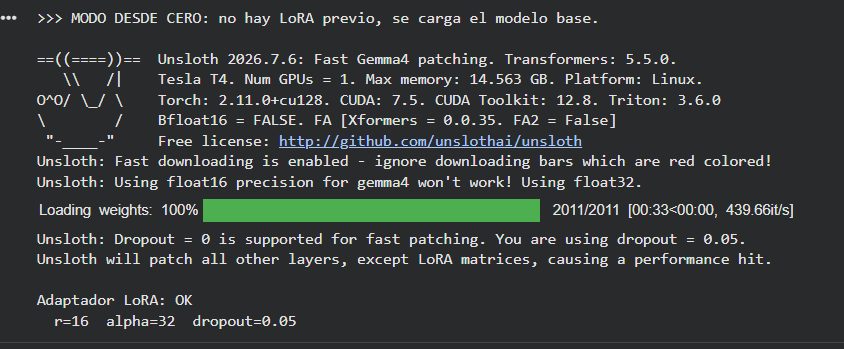

Ahora utilizando la data en JSON con y los nombres de las imagenes preparamos los textos de inferencia para cada imagen

In [ ]:
from PIL import Image, ImageOps

INSTRUCCION = (
    "Extrae de esta factura los siguientes campos y responde ÚNICAMENTE con un JSON válido, "
    "sin texto adicional: ruc (11 dígitos), fecha_emision (YYYY-MM-DD), "
    "numero_factura (tal cual aparece), monto_total (2 decimales, sin símbolo de moneda)."
)

# Por si el JSON trae los campos sueltos en vez de una clave 'respuesta' ya armada
MAPEO_CAMPOS = {
    'ruc':            ['ruc', 'RUC'],
    'fecha_emision':  ['fecha_emision', 'Fecha_Emisión', 'Fecha_Emision', 'fecha'],
    'numero_factura': ['numero_factura', 'Num_factura', 'numero'],
    'monto_total':    ['monto_total', 'Total', 'total', 'monto'],
}

def obtener_respuesta(ej):
    if 'respuesta' in ej:
        return ej['respuesta']
    salida = {}
    for destino, posibles in MAPEO_CAMPOS.items():
        clave = next((k for k in posibles if k in ej), None)
        if clave is None:
            raise KeyError(f"No encuentro '{destino}'. Claves del registro: {list(ej.keys())}")
        salida[destino] = str(ej[clave])
    return json.dumps(salida, ensure_ascii=False)

def cargar_imagen(ruta):
    img = Image.open(ruta)
    img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")
    if RECORTE_SUPERIOR < 1.0:
        w, h = img.size
        img = img.crop((0, 0, w, int(h * RECORTE_SUPERIOR)))
    img.thumbnail((RESOLUCION, RESOLUCION))
    return img

def formatear(ej):
    img = cargar_imagen(Path(RUTA_IMAGENES, ej[CLAVE_IMG]))
    return {"messages": [
        {"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": ej.get('instruccion', INSTRUCCION)},
        ]},
        {"role": "assistant", "content": [
            {"type": "text", "text": obtener_respuesta(ej)},
        ]},
    ]}

dataset_formateado = [formatear(e) for e in datos]

print("Ejemplos formateados:", len(dataset_formateado))
print("Tamaño de la primera imagen:", dataset_formateado[0]["messages"][0]["content"][0]["image"].size)
print("\nRespuesta esperada del primer ejemplo:")
print(dataset_formateado[0]["messages"][1]["content"][0]["text"])

ahora vamos a generar de forma aleatorio una muestra para entrenar y otra para validar

In [ ]:
import random

random.seed(SEMILLA)
indices = list(range(len(dataset_formateado)))
random.shuffle(indices)

n_val = max(5, len(indices) // 5)          # ~20% para validación
idx_val, idx_train = indices[:n_val], indices[n_val:]

train_dataset = [dataset_formateado[i] for i in idx_train]
val_dataset   = [dataset_formateado[i] for i in idx_val]

print(f"Train: {len(train_dataset)} | Validación: {len(val_dataset)}")

ahora corremos el entranamiento utilizando todo lo ya montado (modelo, imagenes, textos) es es variable para para un muestra de 40 fotos no demora muchos minutos

In [ ]:
from trl import SFTTrainer, SFTConfig

try:
    from unsloth.trainer import UnslothVisionDataCollator
except ImportError:
    from unsloth import UnslothVisionDataCollator

collator = UnslothVisionDataCollator(model, tokenizer, resize = RESOLUCION)

config = SFTConfig(
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 4,        # batch efectivo = 4
    num_train_epochs = EPOCAS,
    learning_rate = 2e-4,
    warmup_steps = 5,
    logging_steps = 1,
    output_dir = DIR_CHECKPOINTS,
    optim = "adamw_8bit",
    seed = SEMILLA,
    report_to = "none",
    remove_unused_columns = False,
    dataset_text_field = "",
    dataset_kwargs = {"skip_prepare_dataset": True},
    max_length = 2048,
)

# TRL renombró `tokenizer` a `processing_class`; esto funciona con ambas versiones
try:
    trainer = SFTTrainer(model=model, processing_class=tokenizer,
                         data_collator=collator, train_dataset=train_dataset, args=config)
except TypeError:
    trainer = SFTTrainer(model=model, tokenizer=tokenizer,
                         data_collator=collator, train_dataset=train_dataset, args=config)

trainer.train()

ahora guardamos lo entrenado en el DRVIE para que se mantenga para futuras pruebas si nos desconectamos del colab

In [ ]:
model.save_pretrained(RUTA_MODELO_LORA)
tokenizer.save_pretrained(RUTA_MODELO_LORA)

print("Guardado en:", RUTA_MODELO_LORA)
!ls -la {RUTA_MODELO_LORA}

Ahora evaluamos la seccíon del campo factura

In [ ]:
import re, json
from datetime import datetime

def ruc_valido(ruc):
    """RUC peruano: 11 dígitos, prefijo válido y dígito verificador módulo 11."""
    ruc = str(ruc).strip()
    if not re.fullmatch(r'\d{11}', ruc):          return False, "no son 11 dígitos"
    if ruc[:2] not in ('10', '15', '17', '20'):   return False, f"prefijo {ruc[:2]} inválido"
    pesos = [5, 4, 3, 2, 7, 6, 5, 4, 3, 2]
    suma = sum(int(d) * p for d, p in zip(ruc[:10], pesos))
    resto = 11 - (suma % 11)
    esperado = {10: 0, 11: 1}.get(resto, resto)
    if esperado != int(ruc[10]):                  return False, "dígito verificador no cuadra"
    return True, "ok"

def fecha_valida(f):
    try:
        datetime.strptime(str(f).strip(), "%Y-%m-%d")
        return True, "ok"
    except ValueError:
        return False, "no es YYYY-MM-DD"

def monto_valido(m):
    m = str(m).strip()
    if not re.fullmatch(r'\d+\.\d{2}', m):        return False, "no es un decimal de 2 cifras"
    return True, "ok"

def revisar(pred):
    """Devuelve la lista de campos que habría que revisar a mano."""
    problemas = []
    for campo, fn in (('ruc', ruc_valido), ('fecha_emision', fecha_valida), ('monto_total', monto_valido)):
        ok, motivo = fn(pred.get(campo, ''))
        if not ok:
            problemas.append(f"{campo}: {motivo}")
    return problemas

# --- comprobación del algoritmo con RUCs conocidos ---
for r, esperado in [("20100113610", True), ("20555774045", True),
                    ("20499709944", True), ("20949709944", False)]:
    ok, _ = ruc_valido(r)
    print(("OK " if ok == esperado else "MAL"), r, "->", ok)

con esta parte evaluamos la muestra sacada en el paso anterior de forma puntual

In [ ]:
from unsloth import FastModel

FastModel.for_inference(model)

CAMPOS = ['ruc', 'fecha_emision', 'numero_factura', 'monto_total']
aciertos = {c: 0 for c in CAMPOS}
json_validos = 0
detectados = 0          # errores que la validación estructural habría atrapado

for ej in val_dataset:
    contenido_usuario = ej["messages"][0]["content"]
    real_txt = ej["messages"][1]["content"][0]["text"]

    inputs = tokenizer.apply_chat_template(
        [{"role": "user", "content": contenido_usuario}],
        add_generation_prompt = True,
        tokenize = True,
        return_dict = True,
        return_tensors = "pt",
    ).to("cuda")

    salida = model.generate(**inputs, max_new_tokens=200, do_sample=False)
    nuevos = salida[0][inputs["input_ids"].shape[1]:]      # solo lo generado
    pred_txt = tokenizer.decode(nuevos, skip_special_tokens=True).strip()

    print("Predicho:", pred_txt)
    print("Real:    ", real_txt)

    try:
        pred, real = json.loads(pred_txt), json.loads(real_txt)
        json_validos += 1
        for c in CAMPOS:
            if str(pred.get(c, '')).strip() == str(real.get(c, '')).strip():
                aciertos[c] += 1
        problemas = revisar(pred)
        if problemas:
            detectados += 1
            print("⚠️  Revisar:", "; ".join(problemas))
    except json.JSONDecodeError:
        print("⚠️  JSON inválido")
    print("-" * 70)

n = len(val_dataset)
print(f"\nJSON válidos: {json_validos}/{n}")
for c in CAMPOS:
    print(f"  {c:16} {aciertos[c]}/{n}")
print(f"\nCon algún campo estructuralmente inválido: {detectados}/{n}")
print("(esos son los que la PWA puede marcar para revisión manual sin conocer la respuesta)")

Ahora que ya hemos validado vamos a montar un pequeño servidor para poder hacer que nuestra FINE-TUNNING de gemma 4 este disponible para nuetra APP

In [ ]:
!pip install -q fastapi uvicorn nest_asyncio python-multipart

levantamos el servidor despues de instalar los servicios

In [ ]:
import io, json, threading, time, re
import nest_asyncio, uvicorn
from fastapi import FastAPI, UploadFile, File, Form
from fastapi.responses import JSONResponse
from PIL import Image, ImageOps
from unsloth import FastModel

FastModel.for_inference(model)
nest_asyncio.apply()

app = FastAPI(title="Extractor de facturas")

def preparar(img):
    """Mismo preprocesado que en el entrenamiento. Si difiere, los
    resultados empeoran sin razón aparente."""
    img = ImageOps.exif_transpose(img).convert("RGB")
    if RECORTE_SUPERIOR < 1.0:
        w, h = img.size
        img = img.crop((0, 0, w, int(h * RECORTE_SUPERIOR)))
    img.thumbnail((RESOLUCION, RESOLUCION))
    return img

def extraer_de_imagen(img, prompt):
    inputs = tokenizer.apply_chat_template(
        [{"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": prompt},
        ]}],
        add_generation_prompt = True,
        tokenize = True,
        return_dict = True,
        return_tensors = "pt",
    ).to("cuda")

    salida = model.generate(**inputs, max_new_tokens=200, do_sample=False)
    nuevos = salida[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(nuevos, skip_special_tokens=True).strip()

@app.get("/salud")
def salud():
    return {"estado": "ok", "resolucion": RESOLUCION, "recorte": RECORTE_SUPERIOR}

@app.post("/extraer")
async def extraer(imagen: UploadFile = File(...), prompt: str = Form(INSTRUCCION)):
    try:
        img = preparar(Image.open(io.BytesIO(await imagen.read())))
    except Exception as e:
        return JSONResponse(status_code=400, content={"error": f"imagen ilegible: {e}"})

    crudo = extraer_de_imagen(img, prompt)

    # Parsear y validar. 'revisar' viene del paso 11; si no lo corriste, no pasa nada.
    try:
        campos = json.loads(crudo)
        problemas = revisar(campos) if 'revisar' in globals() else []
        return {"ok": True, "campos": campos,
                "revisar": problemas, "confiable": len(problemas) == 0}
    except json.JSONDecodeError:
        return {"ok": False, "error": "el modelo no devolvió JSON válido", "crudo": crudo}

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning")

threading.Thread(target=run, daemon=True).start()
time.sleep(3)
print("Servidor levantado en el puerto 8000")

consumimos CLAUDFARE para que nos cree el tunel disponible

In [ ]:
import subprocess, time, re, os

URL_CF = ("https://github.com/cloudflare/cloudflared/releases/latest/"
          "download/cloudflared-linux-amd64")

if not os.path.exists("cloudflared"):
    !wget -q -O cloudflared {URL_CF}
    !chmod +x cloudflared

!pkill -f "cloudflared tunnel" 2>/dev/null
!nohup ./cloudflared tunnel --url http://localhost:8000 > /tmp/cf.log 2>&1 &

url = None
for _ in range(30):
    time.sleep(2)
    try:
        log = open("/tmp/cf.log").read()
    except FileNotFoundError:
        continue
    m = re.search(r"https://[a-z0-9-]+\.trycloudflare\.com", log)
    if m:
        url = m.group(0)
        break

if url:
    print("URL pública:", url)
    print("Prueba:     ", url + "/salud")
    print("Endpoint:   ", url + "/extraer")
else:
    print("No se pudo leer la URL. Últimas líneas del log:")
    print(open("/tmp/cf.log").read()[-2000:])

realizamos el consumo desde POSTMAN y validamos que si funciona la** INFERENCIA que despues sera consumida por la APP**

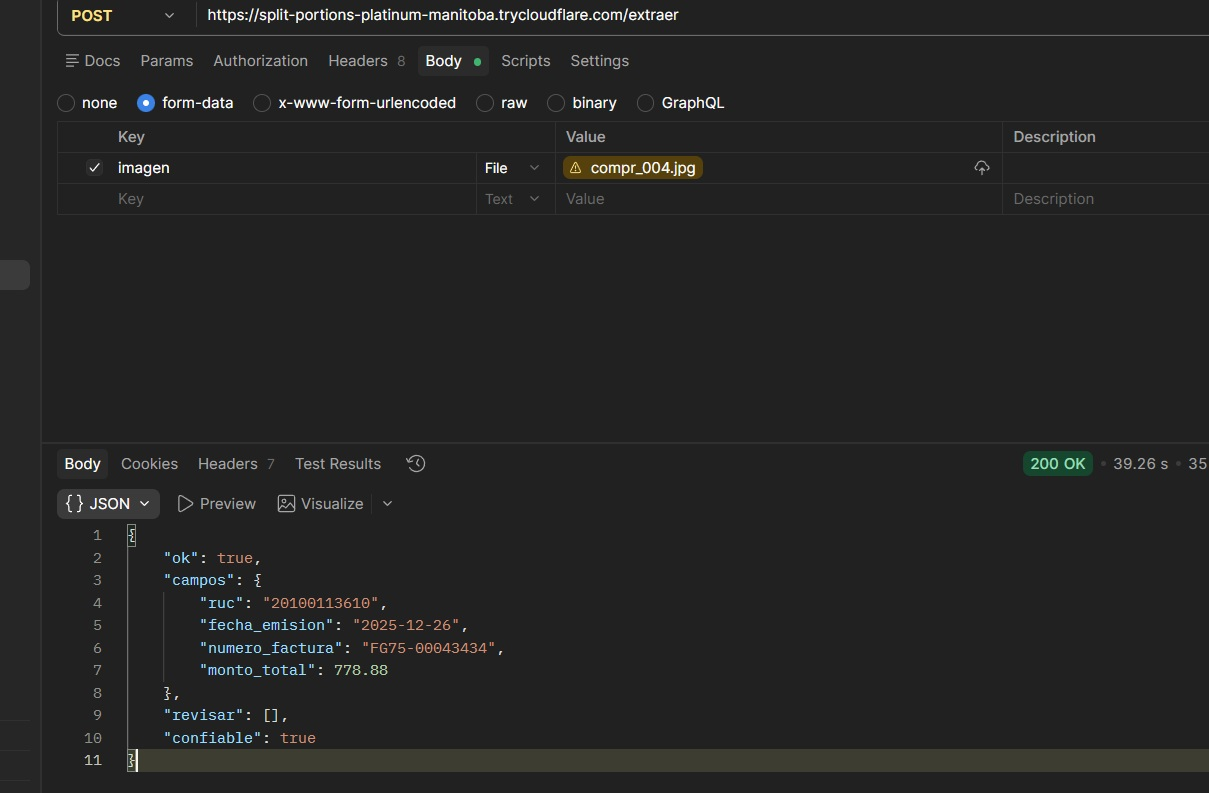